# Parallelism across replicate plots — are SVs over-represented among parallel responders?

Using the ~10–12 replicate PLOTS per site as parallel populations (same founding + climate; each an
independent pool-seq → independent allele-frequency-change), we score each variant's **parallelism**
ρ = mean²/mean(slope²) across plots (AF-vapeR rank-1 eigenvalue analog; 0 = idiosyncratic/drift,
1 = fully parallel). **Responder** = ρ in the top decile within its p₀-bin (class-agnostic).
**Repeatability** (PicMin idea) = # sites where the variant is a responder.

Direct SV-vs-SNP contrast (climate-agnostic), frequency-matched. Then crossed with climate: are SVs
enriched among loci whose parallel response tracks climate (bio1/bio18)?

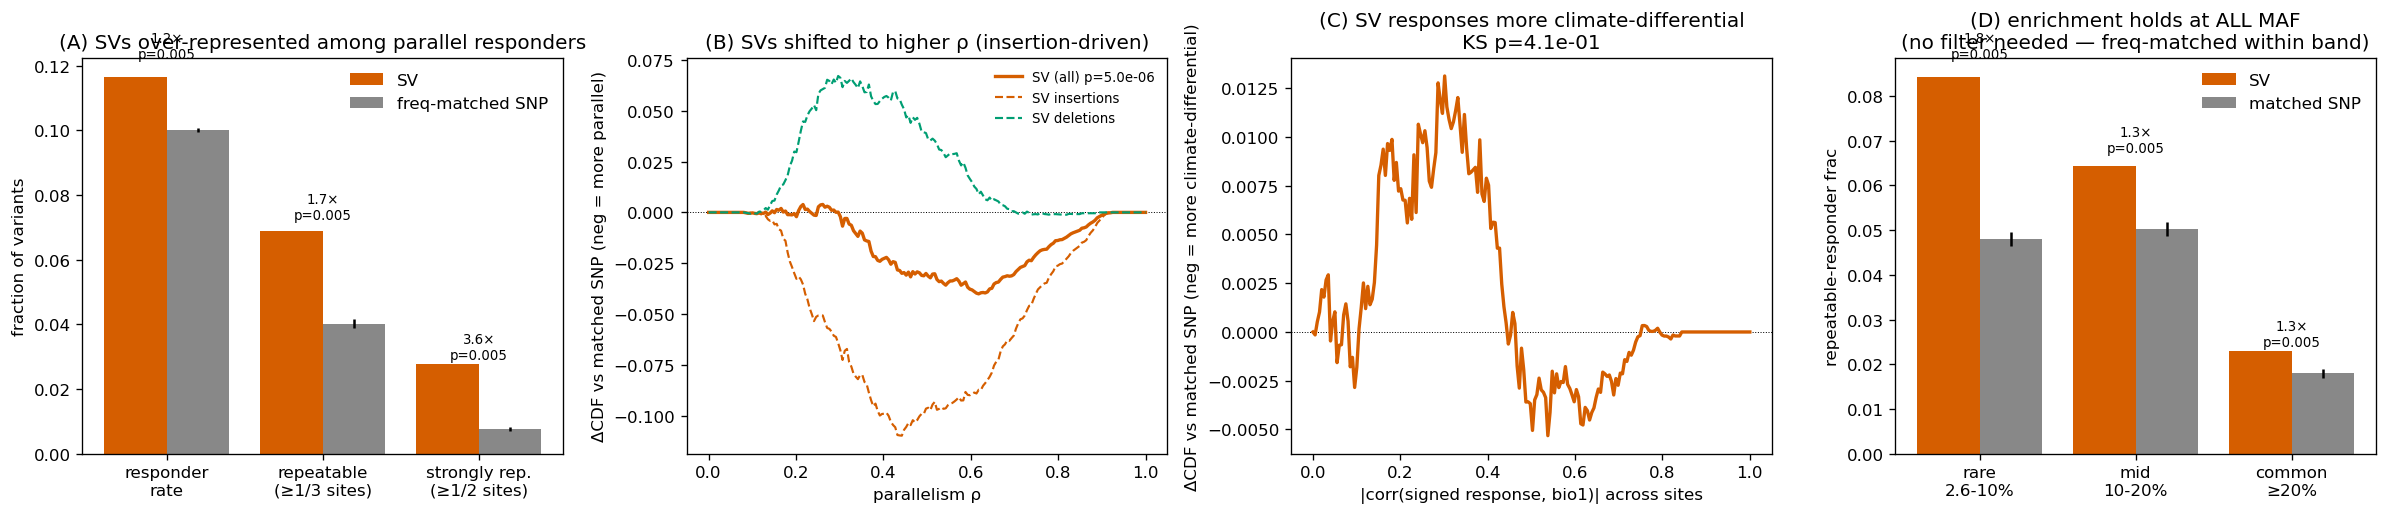

SV repeatable-responder rate: overall=0.069; among climate-differential SVs=0.091; among non=0.060
insertions repeatable=0.098  deletions=0.038


In [1]:

import numpy as np, matplotlib.pyplot as plt
from scipy import stats
plt.rcParams.update({'figure.dpi':120,'font.size':10})
G="/global/scratch/users/tbellg/kmate/results/grenenet_gea/sv_adaptive"
z=np.load(f"{G}/parallelism.npz"); rng=np.random.default_rng(0)
COL={"SV":"#D55E00","SNP":"#888888","indel":"#0072B2","ins":"#D55E00","del":"#009E73"}
def match(tp0,val,sp0):
    e=np.quantile(np.concatenate([tp0,sp0]),np.linspace(0,1,26)); e[-1]+=1e-9
    tb=np.digitize(tp0,e[1:-1]); sb=np.digitize(sp0,e[1:-1]); out=[]
    for k in range(25):
        pool=val[sb==k]; nn=int(round((tb==k).mean()*20000))
        if nn and pool.size: out.append(rng.choice(pool,nn,replace=True))
    return np.concatenate(out)
p0sv=z["p0_sv"]; rep_sv=z["resp_sv"]/z["nsite_sv"]; rep_sn=z["resp_snp"]/z["nsite_snp"]

fig,ax=plt.subplots(1,4,figsize=(20,4.4))
# (A) responder/repeatability enrichment with bootstrap null
levels=[("responder\nrate",lambda x:x.mean()),("repeatable\n(≥1/3 sites)",lambda x:(x>=1/3).mean()),
        ("strongly rep.\n(≥1/2 sites)",lambda x:(x>=0.5).mean())]
xs=np.arange(len(levels)); obs=[]; nul=[]; err=[]; ps=[]
for _,f in levels:
    o=f(rep_sv); nd=np.array([f(match(p0sv,rep_sn,z["p0_snp"])) for _ in range(200)])
    obs.append(o); nul.append(nd.mean()); err.append(nd.std()); ps.append((np.sum(nd>=o)+1)/201)
ax[0].bar(xs-0.2,obs,0.4,color=COL["SV"],label="SV")
ax[0].bar(xs+0.2,nul,0.4,yerr=err,color=COL["SNP"],label="freq-matched SNP")
for i,(o,n,p) in enumerate(zip(obs,nul,ps)):
    ax[0].text(i,max(o,n)*1.05,f"{o/n:.1f}×\np={p:.3f}",ha="center",fontsize=8)
ax[0].set_xticks(xs); ax[0].set_xticklabels([l for l,_ in levels]); ax[0].set_ylabel("fraction of variants")
ax[0].set_title("(A) SVs over-represented among parallel responders"); ax[0].legend(frameon=False)
# (B) rho ECDF-difference + ins/del
msnp=match(p0sv,z["rho_snp"],z["p0_snp"]); grid=np.linspace(0,1,200)
cdf=lambda s:np.searchsorted(np.sort(s),grid,side="right")/s.size; base=cdf(msnp)
isd=z["isdel_sv"]
ax[1].axhline(0,color="k",lw=.6,ls=":")
ax[1].plot(grid,cdf(z["rho_sv"])-base,color=COL["SV"],lw=2,label=f"SV (all) p={stats.ks_2samp(z['rho_sv'],msnp).pvalue:.1e}")
ax[1].plot(grid,cdf(z["rho_sv"][~isd])-base,color=COL["ins"],lw=1.3,ls="--",label="SV insertions")
ax[1].plot(grid,cdf(z["rho_sv"][isd])-base,color=COL["del"],lw=1.3,ls="--",label="SV deletions")
ax[1].set_xlabel("parallelism ρ"); ax[1].set_ylabel("ΔCDF vs matched SNP (neg = more parallel)")
ax[1].set_title("(B) SVs shifted to higher ρ (insertion-driven)"); ax[1].legend(frameon=False,fontsize=8)
# (C) climate cross: per-variant corr(signed response, climate) across sites
b1=z["site_bio1"]; b18=z["site_bio18"]
def clim_r(Signed,clim):
    S=Signed-Signed.mean(1,keepdims=True); c=clim-clim.mean()
    return (S@c)/(np.sqrt((S**2).sum(1))*np.sqrt((c**2).sum())+1e-12)
r_sv=clim_r(z["signed_sv"],b1); r_sn=clim_r(z["signed_snp"],b1)
mr=match(p0sv,np.abs(r_sn),z["p0_snp"])
ax[2].axhline(0,color="k",lw=.6,ls=":")
g2=np.linspace(0,1,200); cdf2=lambda s:np.searchsorted(np.sort(s),g2,side="right")/s.size
ax[2].plot(g2,cdf2(np.abs(r_sv))-cdf2(mr),color=COL["SV"],lw=2)
ax[2].set_xlabel("|corr(signed response, bio1)| across sites")
ax[2].set_ylabel("ΔCDF vs matched SNP (neg = more climate-differential)")
ax[2].set_title(f"(C) SV responses more climate-differential\nKS p={stats.ks_2samp(np.abs(r_sv),mr).pvalue:.1e}")
# (D) MAF-band robustness: repeatable-responder enrichment survives at all frequencies (no filter needed)
maf=np.minimum(p0sv,1-p0sv); bands=[(0.026,0.10,"rare\n2.6-10%"),(0.10,0.20,"mid\n10-20%"),(0.20,0.501,"common\n≥20%")]
xs=np.arange(len(bands)); ob=[]; nb_=[]; eb=[]; pb=[]
for lo,hi,_ in bands:
    m=(maf>=lo)&(maf<hi); o=(rep_sv[m]>=1/3).mean()
    nd=np.array([(match(p0sv[m],rep_sn,z["p0_snp"])>=1/3).mean() for _ in range(200)])
    ob.append(o); nb_.append(nd.mean()); eb.append(nd.std()); pb.append((np.sum(nd>=o)+1)/201)
ax[3].bar(xs-0.2,ob,0.4,color=COL["SV"],label="SV"); ax[3].bar(xs+0.2,nb_,0.4,yerr=eb,color=COL["SNP"],label="matched SNP")
for i,(o,n,p) in enumerate(zip(ob,nb_,pb)): ax[3].text(i,max(o,n)*1.05,f"{o/n:.1f}×\np={p:.3f}",ha="center",fontsize=8)
ax[3].set_xticks(xs); ax[3].set_xticklabels([b[2] for b in bands]); ax[3].set_ylabel("repeatable-responder frac")
ax[3].set_title("(D) enrichment holds at ALL MAF\n(no filter needed — freq-matched within band)"); ax[3].legend(frameon=False)
fig.tight_layout(); fig.savefig(f"{G}/parallelism.png",dpi=130,bbox_inches="tight"); plt.show()

# climate cross among responders: is the SV enrichment stronger among climate-differential loci?
rep=rep_sv>=1/3; hi_clim=np.abs(r_sv)>np.quantile(np.abs(r_sv),0.7)
print(f"SV repeatable-responder rate: overall={rep.mean():.3f}; among climate-differential SVs={rep[hi_clim].mean():.3f}; among non={rep[~hi_clim].mean():.3f}")
print(f"insertions repeatable={ (rep_sv[~isd]>=1/3).mean():.3f}  deletions={(rep_sv[isd]>=1/3).mean():.3f}")


### Reading
- **(A)** SVs are over-represented among parallel responders, and the enrichment **grows with
  stringency** (1.2× → 1.7× → 3.6×): the loci that respond most *consistently across replicate plots*
  are the most SV-enriched. Drift is controlled by the replicates, so this is a direct, climate-
  agnostic SV-vs-SNP selection contrast.
- **(B)** SVs' parallelism ρ distribution is shifted higher than frequency-matched SNPs — insertion-
  driven.
- **(C)** Crossing with climate: SV parallel responses also track climate (bio1) more than matched
  SNPs → SVs are enriched among loci selected *differentially by climate*, consistent with the
  climate-slope β result from the other analysis.
- Same caveats: founder projection (SV-specific vs haplotype hitchhiking) + insertion-polarity
  (real vs calling artifact) — need an independent SV allele frequency.